# 시각화 프로젝트

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LinearRegression            # 선형모델 : 회귀
#from sklearn.linear_model import LogisticRegression         # 선형모델 : 분류
from sklearn.tree import DecisionTreeRegressor               # 트리모델
from sklearn.ensemble import RandomForestRegressor           # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMRegressor                           # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold   #, StratifiedKFold XXXXXX
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

#-----------------------------------------------------------------------------------  파이프라인
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

In [9]:
#Default theme
sns.set_theme(font='Comic Sans MS',
              font_scale=1.5,
              rc=None)


## 데이터 불러오기 및 기본 EDA

### 데이터 로딩

In [10]:
raw_data = pd.read_csv("Steel_industry_data.csv")

In [11]:
raw_data.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### 자동 EDA(ydata_profiling)

In [12]:
## 생성 후 주석처리
# from ydata_profiling import ProfileReport
# res = ProfileReport(raw_data, title="automatic EDA Report for Steel Industry Data", explorative=True)
# res.to_file('steel_industry_report.html')

In [13]:
# 에러로 인해 활용하지 않음
# import sweetviz as sv

# # 1. 단일 데이터셋 분석
# report = sv.analyze(raw_data)
# report.show_html("steel_industry_report2.html")

# # 2. 타겟 변수 설정 시 (예: Usage_kWh 분석)
# report_target = sv.analyze(raw_data, target_feat='Usage_kWh')
# report_target.show_html("steel_industry_report2_for_Usage_kWh.html")

# # 3. 두 그룹 비교 (예: 특정 공정 유무에 따른 차이)
# # report_comp = sv.compare([train_df, "Train Data"], [test_df, "Test Data"])
# # report_comp.show_html("compare_report.html")

In [14]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

### 1차원 EDA

#### 그래프

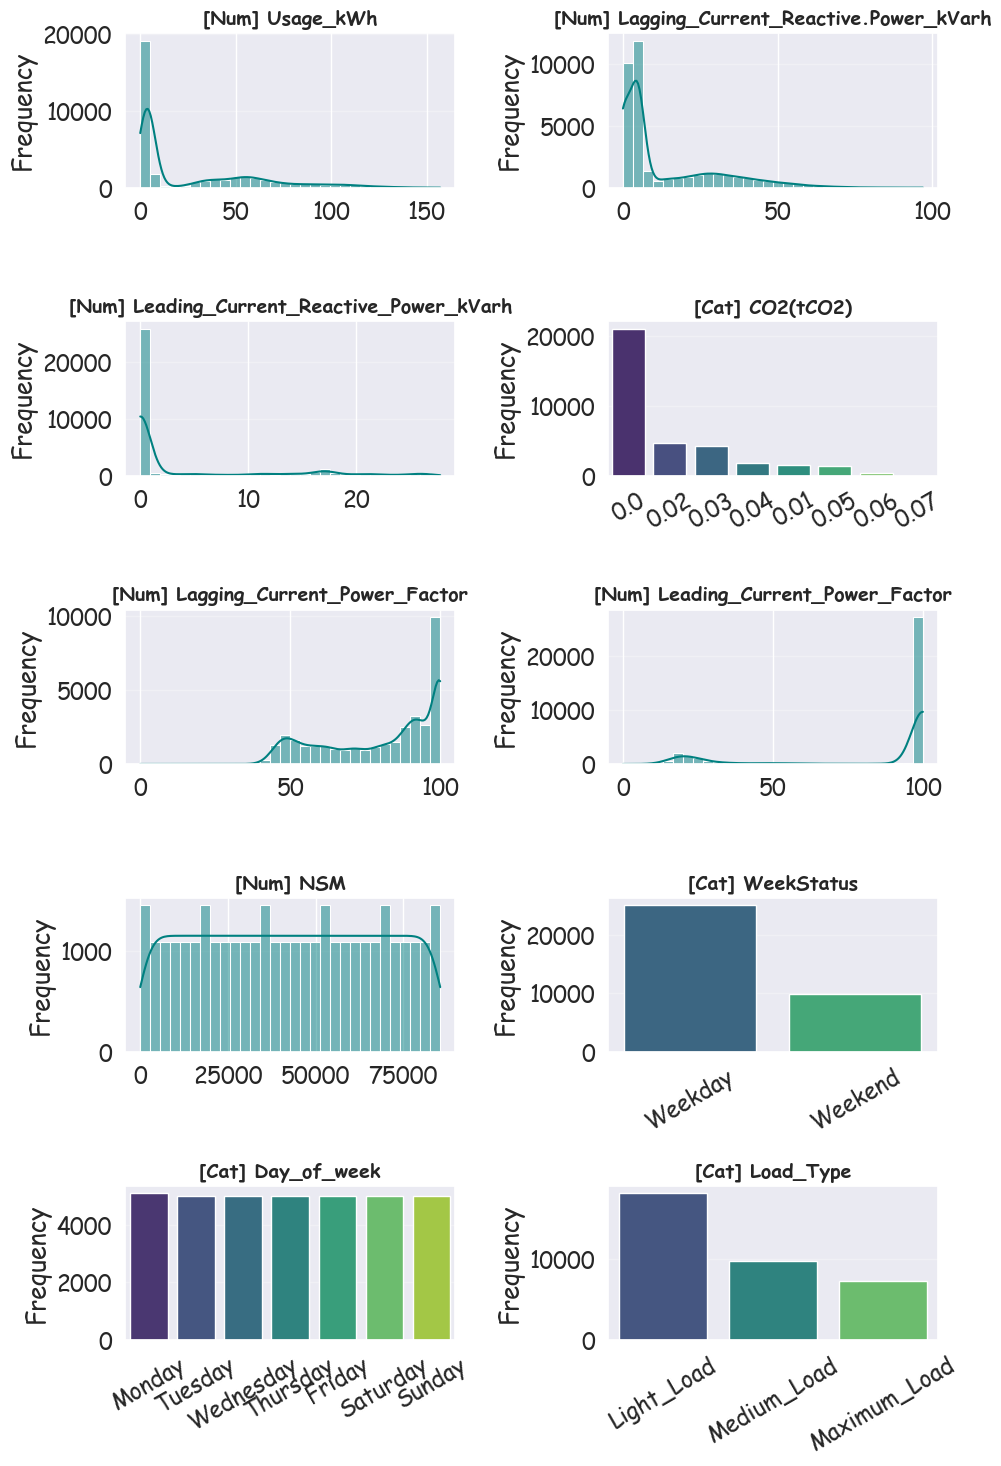

In [15]:
# 1. 분석할 10개 피처 리스트 (데이터 상황에 맞게 조정)
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']


# 2. 5행 2열 그리드 설정 (가로로 길게 보는 것보다 세로로 나열하는 것이 가독성이 좋음)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    #### 3. 여기서 딱 한 번만 언급: 분석할 데이터를 짧은 변수에 할당
    curr_data = raw_data[col]
    ax = axes[i]
    
    # 이후로는 curr_data와 ax만 사용하여 로직 집중
    # 데이터 타입 또는 유니크 값 개수에 따라 차트 종류 결정
    # 유니크 값이 적으면 범주형으로 판단하여 countplot 적용
    if curr_data.dtype == 'object' or curr_data.nunique() < 10:
        # 카운트플롯의 경우 정렬을 위해 value_counts()를 한 번 더 쓰지만 흐름은 깔끔함
        sns.countplot(x=curr_data, ax=ax, palette='viridis', 
                      order=curr_data.value_counts().index)
        ax.set_title(f'[Cat] {col}', fontsize=14, fontweight='bold')
        # 라벨이 겹치지 않게 회전 처리
        ax.tick_params(axis='x', rotation=30)
    else:
        # 수치형 데이터는 도수분포의 기본인 histplot 적용
        sns.histplot(curr_data, kde=True, ax=ax, color='teal', bins=30)
        ax.set_title(f'[Num] {col}', fontsize=14, fontweight='bold')

    # 공통 설정
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 도수분포표

In [20]:
# 1. 분석할 10개 피처 리스트 (데이터 상황에 맞게 조정)
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

print("=== 피처별 도수분포표 (Frequency Table) 분석 ===\n")

for col in cols:
    print(f"[{col}]")
    
    # 1. 데이터 선택 및 분석 로직을 하나의 흐름으로 구성
    summary = raw_data[col].pipe(lambda s: 
        # 범주형/유니크 적은 경우 그대로, 수치형은 10개 구간(cut) 적용
        (pd.cut(s, bins=10) if s.dtype != 'object' and s.nunique() >= 10 else s)
    ).value_counts().sort_index().pipe(lambda counts:
        # 최종 결과를 데이터프레임으로 변환 및 비율 계산
        pd.DataFrame({
            'Count': counts,
            'Percentage(%)': (counts / counts.sum()) * 100
        })
    )
    
    print(summary)
    print("-" * 50)


=== 피처별 도수분포표 (Frequency Table) 분석 ===

[Usage_kWh]
                    Count  Percentage(%)
Usage_kWh                               
(-0.157, 15.718]    21119      60.271119
(15.718, 31.436]     1116       3.184932
(31.436, 47.154]     3021       8.621575
(47.154, 62.872]     4055      11.572489
(62.872, 78.59]      2275       6.492580
(78.59, 94.308]      1336       3.812785
(94.308, 110.026]    1174       3.350457
(110.026, 125.744]    689       1.966324
(125.744, 141.462]    224       0.639269
(141.462, 157.18]      31       0.088470
--------------------------------------------------
[Lagging_Current_Reactive.Power_kVarh]
                                      Count  Percentage(%)
Lagging_Current_Reactive.Power_kVarh                      
(-0.0969, 9.691]                      23325      66.566781
(9.691, 19.382]                        2051       5.853311
(19.382, 29.073]                       3114       8.886986
(29.073, 38.764]                       2988       8.527397
(38.764, 48.

왜도, 첨도

In [19]:
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

print("=== 피처별 왜도(Skew) 및 첨도(Kurtosis) 리포트 ===")

# df_incoded는 여기서 딱 한 번만 등장합니다.
raw_data[cols].select_dtypes(include=['number']).pipe(lambda d: pd.DataFrame({
    'Skewness': d.skew(),
    'Kurtosis': d.kurt()
})).sort_values(by='Skewness', ascending=False).style.apply(lambda s: [
    'background-color: #ffcccc' if abs(v) > 2 else '' for v in s
])

=== 피처별 왜도(Skew) 및 첨도(Kurtosis) 리포트 ===


,Skewness,Kurtosis
Leading_Current_Reactive_Power_kVarh,1.734314,1.581097
Lagging_Current_Reactive.Power_kVarh,1.437899,1.213836
Usage_kWh,1.197394,0.391386
CO2(tCO2),1.149355,0.214605
NSM,0.000000,-1.200260
Lagging_Current_Power_Factor,-0.606126,-1.095824
Leading_Current_Power_Factor,-1.511984,0.383301


In [17]:
raw_data.iloc[90:100, :]
## index 23:45 -> 00:00 으로 변환 시 date의 오류 여부 확인해보았으나 
# 이후 데이터로 비슷한 양상을 보이고 day_of_week에서는 해당 날짜가 monday로 찍히는 것으로 보아
# 23:45 -> 00:00으로 변환 시 date의 오류는 없는 것으로 보임.
# 아마도 기입 시의 순서 오류가 아닐까 추정

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
90,01/01/2018 22:45,3.24,3.35,0.0,0.0,69.52,100.0,81900,Weekday,Monday,Light_Load
91,01/01/2018 23:00,3.53,3.74,0.0,0.0,68.64,100.0,82800,Weekday,Monday,Light_Load
92,01/01/2018 23:15,3.53,3.42,0.0,0.0,71.82,100.0,83700,Weekday,Monday,Light_Load
93,01/01/2018 23:30,3.24,2.95,0.0,0.0,73.94,100.0,84600,Weekday,Monday,Light_Load
94,01/01/2018 23:45,3.67,3.96,0.0,0.0,67.97,100.0,85500,Weekday,Monday,Light_Load
95,01/01/2018 00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
96,02/01/2018 00:15,3.20,3.10,0.0,0.0,71.82,100.0,900,Weekday,Tuesday,Light_Load
97,02/01/2018 00:30,3.85,4.61,0.0,0.0,64.10,100.0,1800,Weekday,Tuesday,Light_Load
98,02/01/2018 00:45,3.28,3.67,0.0,0.0,66.64,100.0,2700,Weekday,Tuesday,Light_Load
99,02/01/2018 01:00,3.35,3.60,0.0,0.0,68.12,100.0,3600,Weekday,Tuesday,Light_Load


### 2차원 EDA

In [16]:
raw_data[['WeekStatus', 'Day_of_week']].value_counts()

WeekStatus  Day_of_week
Weekday     Monday         5088
            Friday         4992
            Thursday       4992
            Tuesday        4992
            Wednesday      4992
Weekend     Saturday       4992
            Sunday         4992
Name: count, dtype: int64

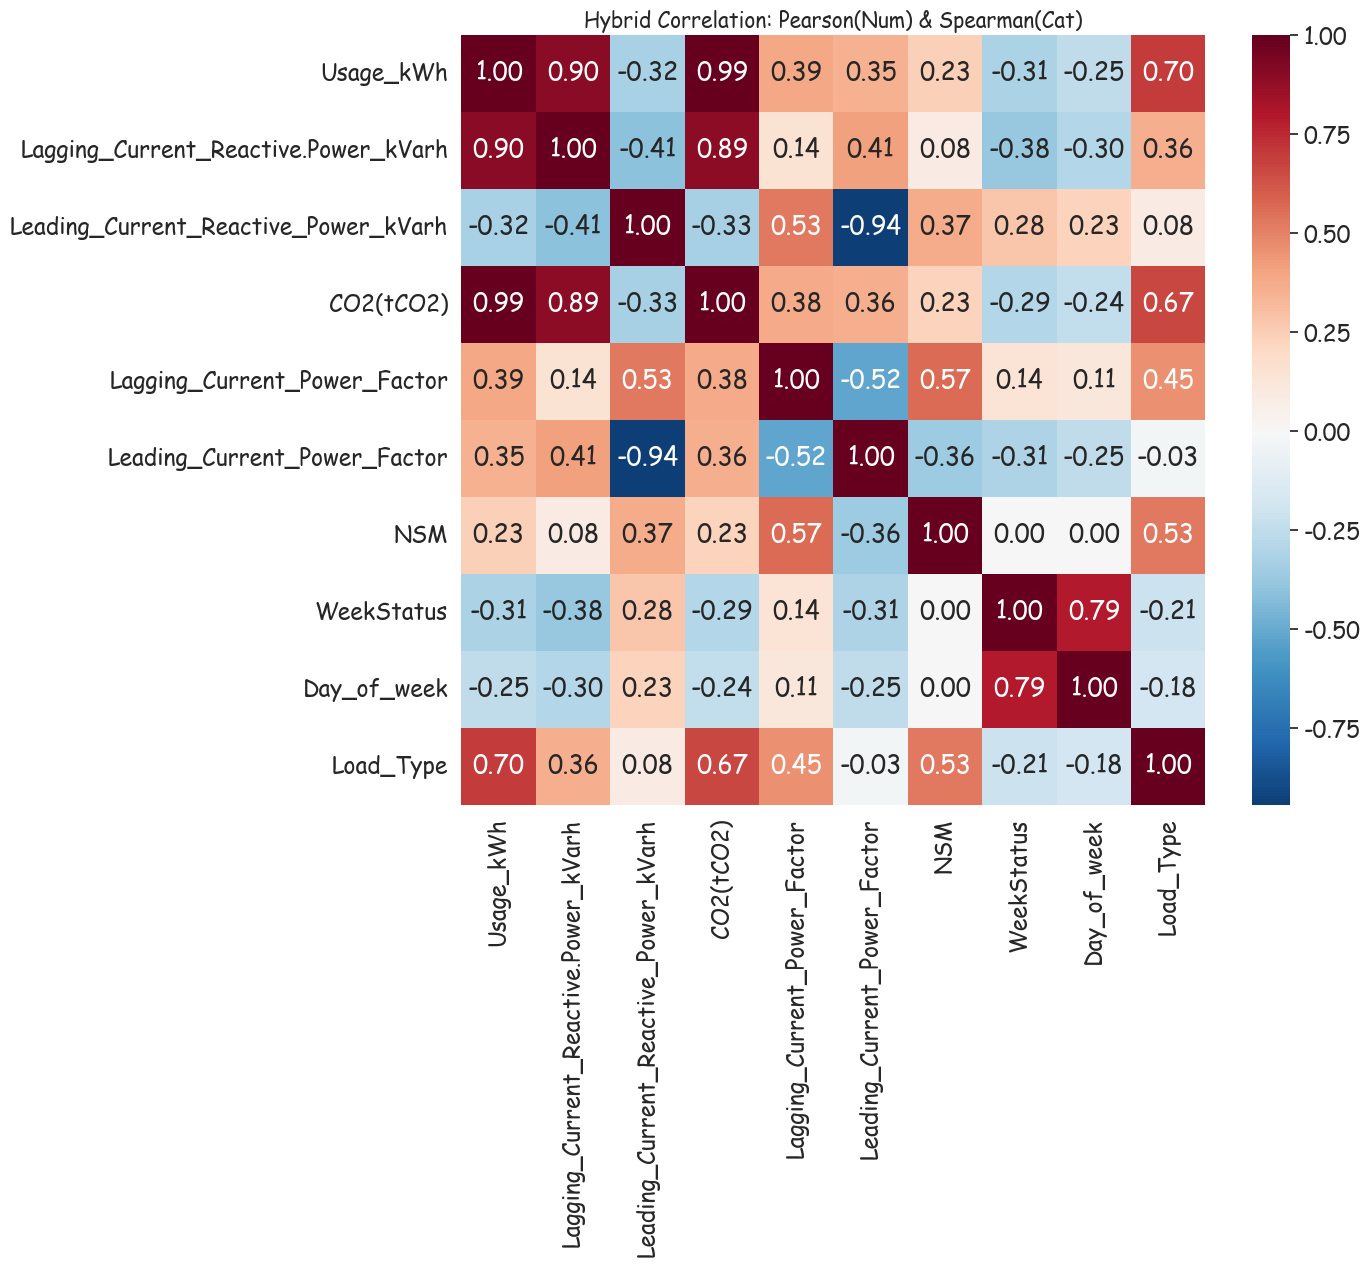

In [23]:


# 1. 사용자가 직접 컬럼 성격 분류 (가장 확실한 방법)
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']  # 범주형
num_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM'
       ]

# 1. 계산 로직을 담은 함수 (df 언급 최소화용)
def calculate_hybrid_corr(df, num_cols, cat_cols):
    all_cols = num_cols + cat_cols
    # 범주형 컬럼만 임시로 숫자로 변환 (Factorize)
    temp_df = df[all_cols].copy()
    for col in cat_cols:
        temp_df[col] = temp_df[col].factorize()[0]
    
    # 빈 행렬 생성
    corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols)
    
    for c1 in all_cols:
        for c2 in all_cols:
            # 하나라도 범주형이면 spearman, 둘 다 수치형이면 pearson
            method = 'spearman' if (c1 in cat_cols or c2 in cat_cols) else 'pearson'
            corr_matrix.loc[c1, c2] = temp_df[c1].corr(temp_df[c2], method=method)
            
    return corr_matrix.astype(float)

# 2. 통합 실행부 (raw_data는 여기서 딱 한 번만 언급)
integrated_corr = raw_data.pipe(calculate_hybrid_corr, num_cols=num_cols, cat_cols=cat_cols)

# 3. 시각화
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(integrated_corr, dtype=bool))
sns.heatmap(integrated_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Hybrid Correlation: Pearson(Num) & Spearman(Cat)', fontsize=15)
plt.show()

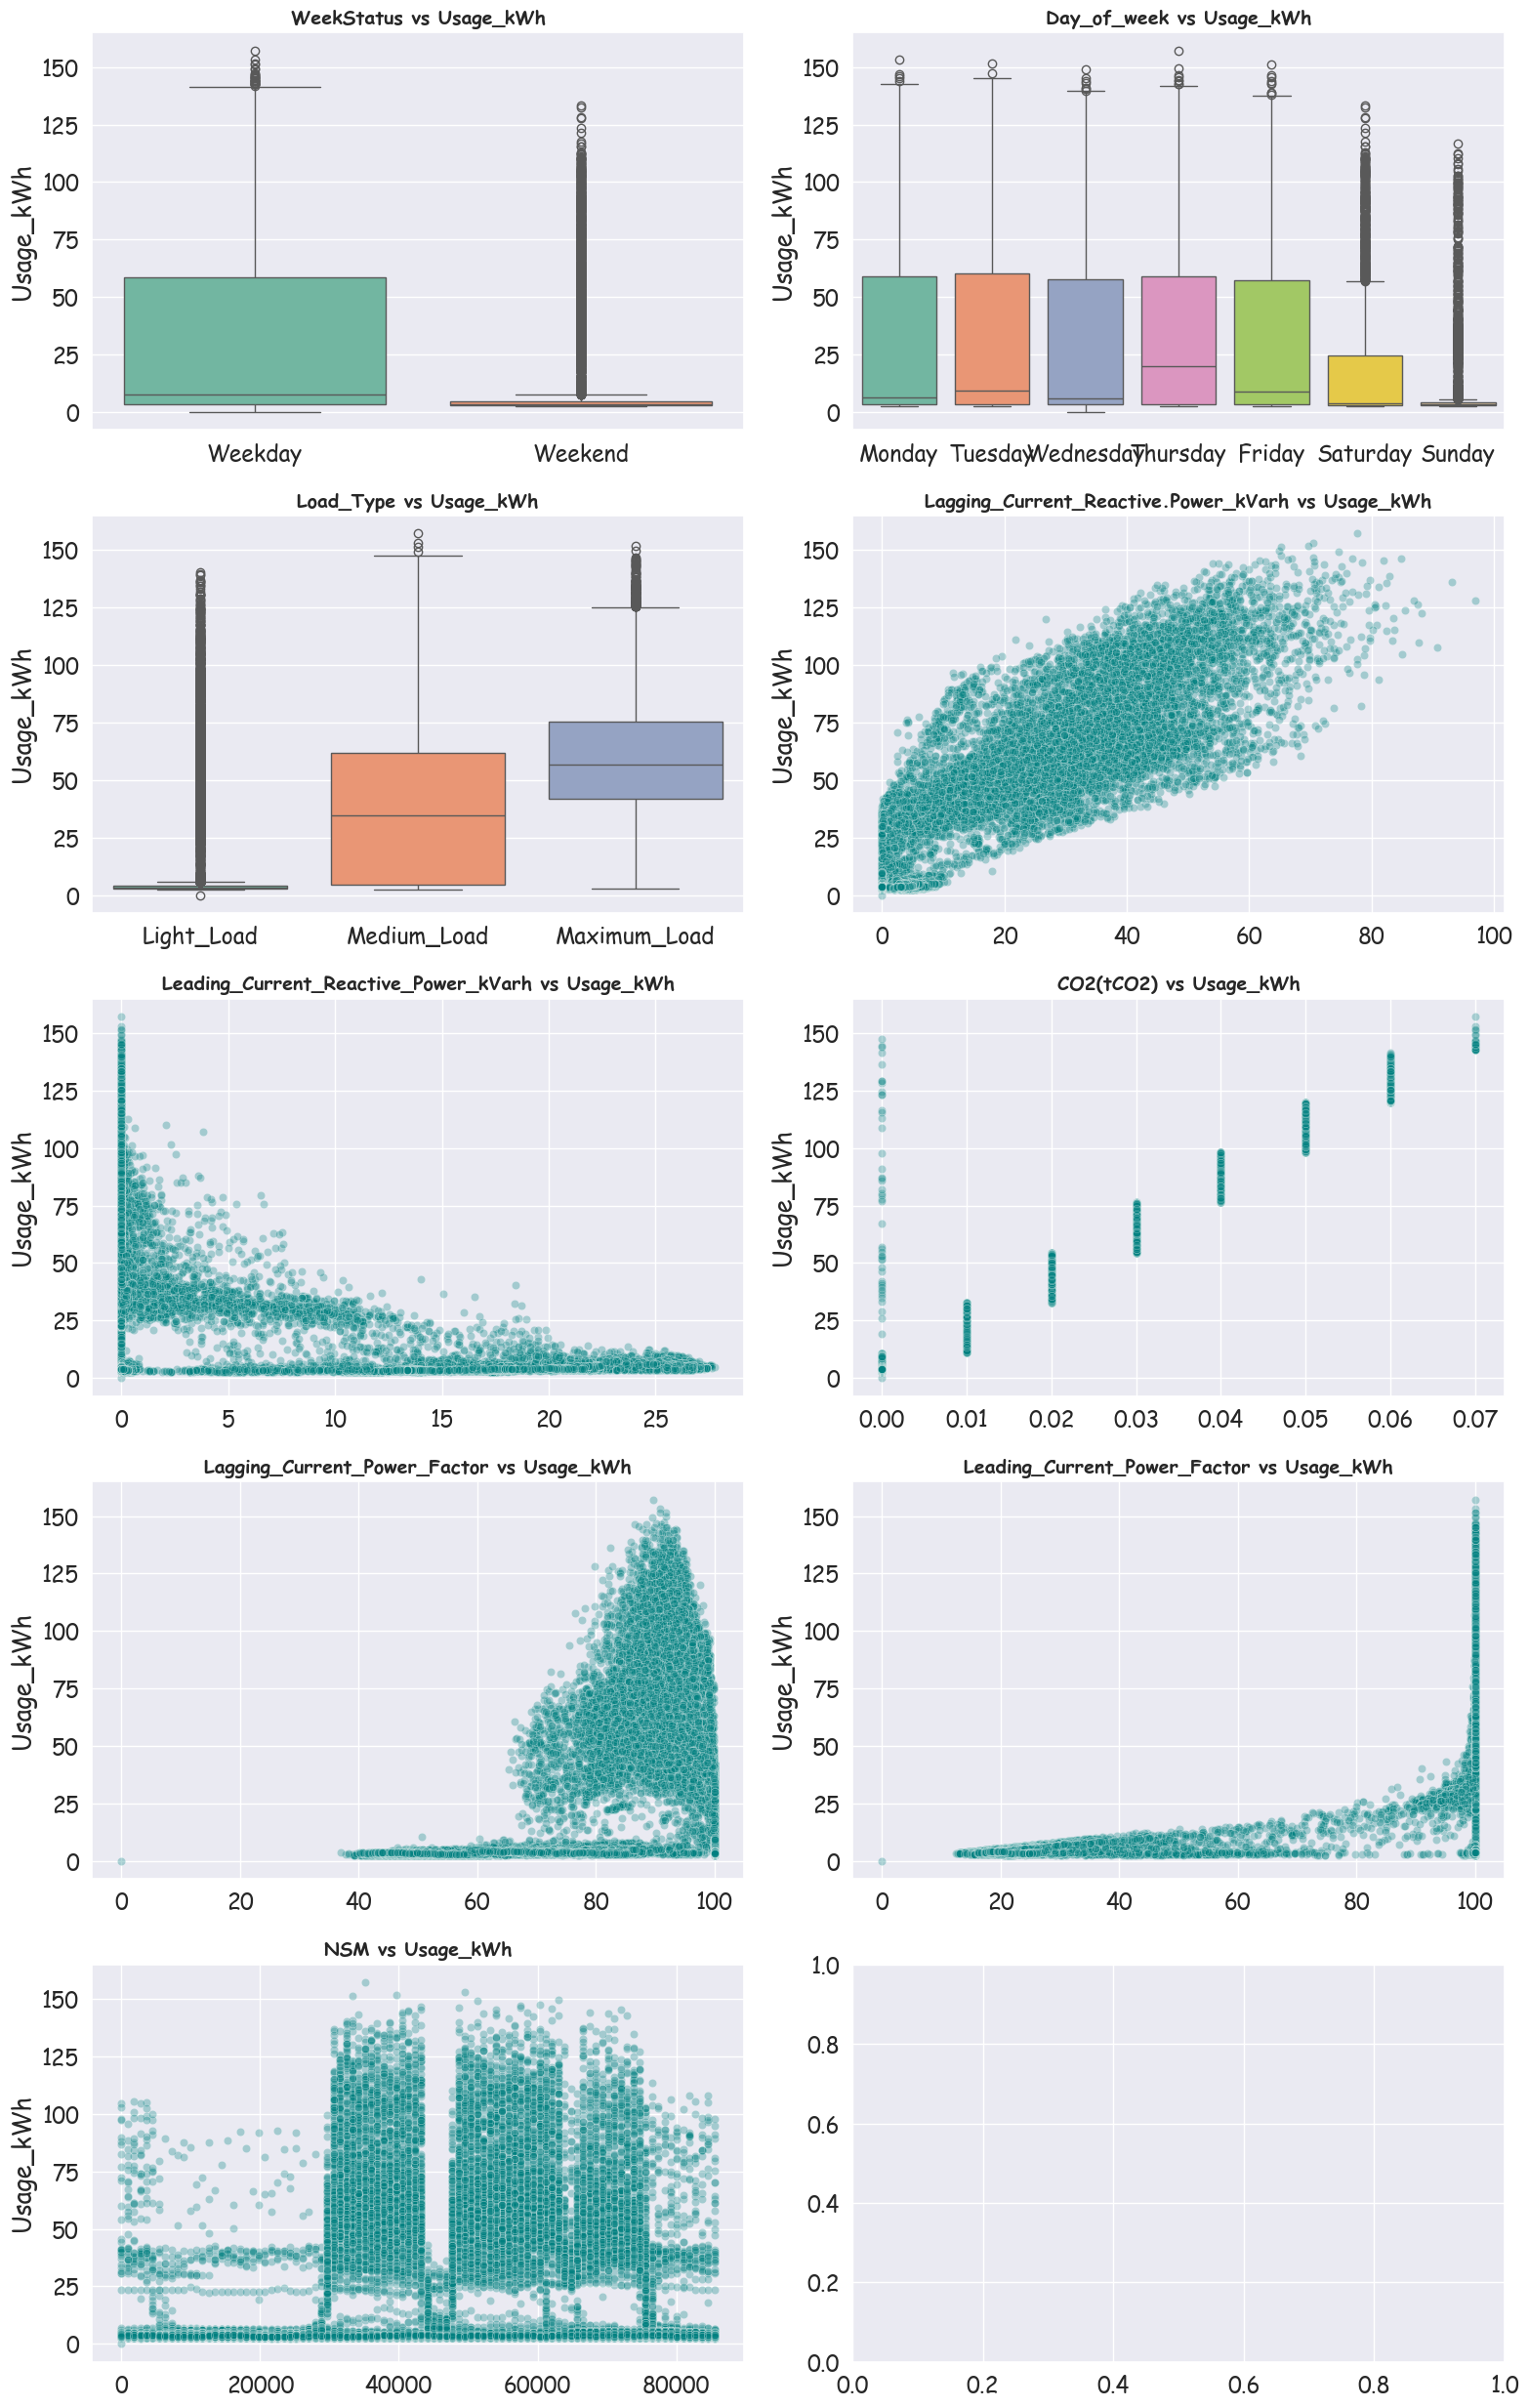

In [25]:
# 1. 컬럼 분류
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']  # 범주형
num_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM'
       ]
# 1. 변수 선언 (여기서만 각각 1회씩 등장)
target = 'Usage_kWh'
data_source = raw_data

# 2. 실행 로직 (이하에서는 위 변수들을 참조만 함)
all_target_cols = [c for c in (cat_cols + num_cols) if c != target]

fig, axes = plt.subplots(nrows=(len(all_target_cols) + 1) // 2, ncols=2, figsize=(16, 25))

_ = [
    (sns.boxplot(data=data_source, x=col, y=target, ax=ax, palette='Set2') 
     if col in cat_cols else 
     sns.scatterplot(data=data_source, x=col, y=target, ax=ax, alpha=0.3, color='teal'),
     ax.set_title(f'{col} vs {target}', fontsize=14, fontweight='bold'),
     ax.set_xlabel(''), ax.set_ylabel(target))
    for col, ax in zip(all_target_cols, axes.flatten())
]

plt.tight_layout()
plt.show()